# Telecom X – Predicción de Cancelación de Clientes

En esta etapa se desarrollarán modelos predictivos para identificar
clientes con mayor probabilidad de cancelar el servicio (Churn).

Se utilizará el dataset previamente tratado en la Parte 1, aplicando
técnicas de preparación de datos, análisis exploratorio, entrenamiento
de modelos de machine learning y evaluación de resultados

### Objetivo del proyecto

El objetivo de este proyecto es analizar los factores asociados a la cancelación de clientes en Telecom X y desarrollar modelos predictivos que permitan identificar clientes con alto riesgo de churn, con el fin de apoyar estrategias de retención basadas en datos.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

In [2]:
url = 'https://drive.google.com/uc?export=download&id=1TtqrjV4DM2xczpzxur1XFZVP_lzBJiZ9'
datos = pd.read_csv(url)

datos.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


In [3]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7043 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [4]:
datos.describe()

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
count,7267.000000,7267.000000,7267.000000,7256.000000,7267.000000
mean,0.162653,32.346498,64.720098,2280.634213,2.157337
std,0.369074,24.571773,30.129572,2268.632997,1.004319
min,0.000000,0.000000,18.250000,18.800000,0.608333
25%,0.000000,9.000000,35.425000,400.225000,1.180833
50%,0.000000,29.000000,70.300000,1391.000000,2.343333
75%,0.000000,55.000000,89.875000,3785.300000,2.995833
max,1.000000,72.000000,118.750000,8684.800000,3.958333


In [5]:
datos.isnull().sum()

,0
customerID,0
Churn,224
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


Eliminación de columnas

Eliminamos columnas que no aportan valor al analisis o a los modelos predictivos, como identificadores unicos.

In [6]:
datos.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total', 'Cuentas_Diarias'],
      dtype='object')

In [7]:
datos = datos.drop(columns=['customerID'])

In [8]:
datos.columns

Index(['Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total', 'Cuentas_Diarias'],
      dtype='object')

In [9]:
cols_to_fix = [
    'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection',
    'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies'
]

for col in cols_to_fix:
    datos[col] = datos[col].replace({'No internet service': 'No'})

In [10]:
datos = datos.dropna()

In [11]:
datos.isnull().sum()

,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0
internet.OnlineSecurity,0


Analisis Exploratorio

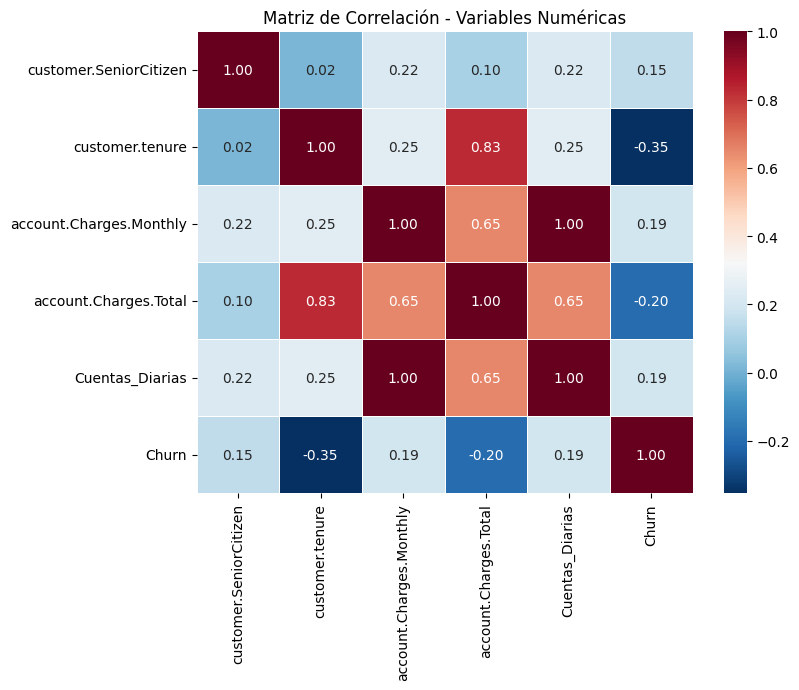

In [12]:
datos_num = datos.select_dtypes(include=['int64', 'float64'])

# Convertir Churn a numérico para correlación
datos_num["Churn"] = datos["Churn"].map({"Yes": 1, "No": 0})

matriz_correlacion = datos_num.corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(
    matriz_correlacion,
    annot=True,
    cmap="RdBu_r",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matriz de Correlación - Variables Numéricas")

plt.show()

Observaciones

Existe una correlación negativa moderada entre customer.tenure y Churn, lo que indica que los clientes con mayor antigüedad tienden a cancelar menos.   

account.Charges.Total también presenta correlación negativa con la cancelación, asociada  con la antigüedad del cliente.

El gasto mensual muestra una correlación positiva con la cancelación.

## Análisis
Se analizan relaciones específicas entre variables clave y la cancelación de clientes para la identificacion de patrones con importancia.


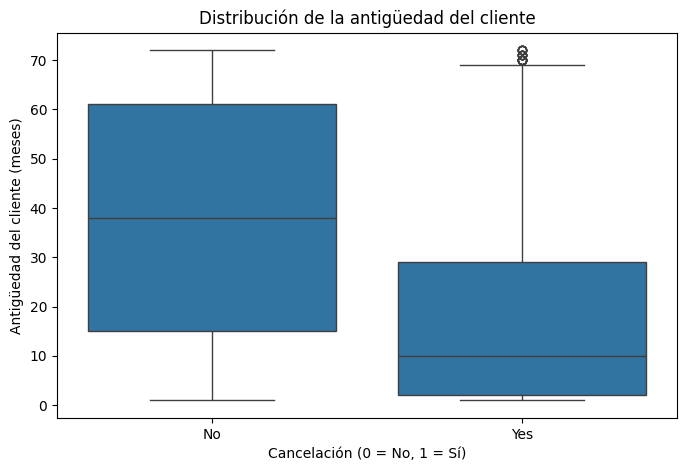

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="Churn",
    y="customer.tenure",
    data = datos
)
plt.title("Distribución de la antigüedad del cliente")
plt.xlabel("Cancelación (0 = No, 1 = Sí)")
plt.ylabel("Antigüedad del cliente (meses)")
plt.show()

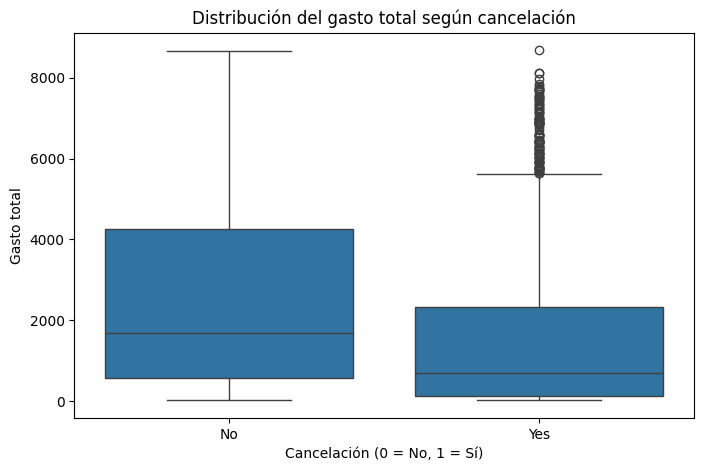

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="Churn",
    y="account.Charges.Total",
    data = datos
)
plt.title("Distribución del gasto total según cancelación")
plt.xlabel("Cancelación (0 = No, 1 = Sí)")
plt.ylabel("Gasto total")
plt.show()

Los clientes que cancelan el servicio suelen tener menos tiempo de antigüedad en la empresa en comparación con los que continúan activos.

También se observa que los clientes que cancelan presentan un gasto total acumulado menor, lo que puede explicarse por el menor tiempo que permanecen utilizando el servicio.

En general, los clientes con mayor tiempo de contrato tienden a generar un mayor valor para la empresa y muestran una menor tendencia a cancelar el servicio.

### Separación de los datos en entrenamiento y prueba

El conjunto de datos se divide en dos partes: una para entrenar el modelo y otra para probar su desempeño. Esto permite evaluar qué tan bien el modelo puede realizar predicciones utilizando datos nuevos.

In [15]:
X = datos.drop(columns=["Churn"])
y = datos["Churn"]


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

### Encoding y preprocesamiento de los datos

En esta etapa se transforman las variables categóricas a valores numéricos y se realizan algunos ajustes en los datos para prepararlos antes de entrenar los modelos de Machine Learning.

In [17]:
categorical_cols = X.select_dtypes(include=["object"]).columns
datos_num = X.select_dtypes(include=["int64", "float64"]).columns

categorical_cols, datos_num

(Index(['customer.gender', 'customer.Partner', 'customer.Dependents',
        'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
        'internet.OnlineSecurity', 'internet.OnlineBackup',
        'internet.DeviceProtection', 'internet.TechSupport',
        'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
        'account.PaperlessBilling', 'account.PaymentMethod'],
       dtype='object'),
 Index(['customer.SeniorCitizen', 'customer.tenure', 'account.Charges.Monthly',
        'account.Charges.Total', 'Cuentas_Diarias'],
       dtype='object'))

In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", datos_num)
    ]
)

In [19]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_train_processed.shape, X_test_processed.shape

((4922, 29), (2110, 29))

In [20]:
("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore"), categorical_cols),
("num", "passthrough", datos_num)

('num',
 'passthrough',
 Index(['customer.SeniorCitizen', 'customer.tenure', 'account.Charges.Monthly',
        'account.Charges.Total', 'Cuentas_Diarias'],
       dtype='object'))

In [21]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_train_processed.shape, X_test_processed.shape

((4922, 29), (2110, 29))

El proceso de codificación dio como resultado un conjunto de datos con 29 variables finales, que combinan variables numéricas y variables categóricas transformadas mediante one-hot encoding.

### Modelos de clasificación

In [22]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train_processed, y_train)

y_pred_dummy = dummy.predict(X_test_processed)

#### Modelo 1 Árbol de Decisión

In [23]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_processed, y_train)

y_pred_dt = dt.predict(X_test_processed)

#### Modelo 2  Regresión Logística

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression

logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("scaler", MinMaxScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

logreg_pipeline.fit(X_train, y_train)
y_pred_logreg = logreg_pipeline.predict(X_test)

#### Evaluación

In [25]:
def evaluar_modelo(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, pos_label='Yes'),
        "Recall": recall_score(y_true, y_pred, pos_label='Yes'),
        "F1-score": f1_score(y_true, y_pred, pos_label='Yes')
    }

In [26]:
resultados = {
    "Baseline (Dummy)": evaluar_modelo(y_test, y_pred_dummy),
    "Árbol de Decisión": evaluar_modelo(y_test, y_pred_dt),
    "Regresión Logística": evaluar_modelo(y_test, y_pred_logreg)
}

resultados_df = pd.DataFrame(resultados).T
resultados_df

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Accuracy,Precision,Recall,F1-score
Baseline (Dummy),0.734123,0.000000,0.000000,0.000000
Árbol de Decisión,0.723697,0.482201,0.531194,0.505513
Regresión Logística,0.801896,0.656455,0.534759,0.589391


#### Conclusión

Al comparar los modelos evaluados, la Regresión Logística mostró el mejor desempeño general, obteniendo los valores más altos en accuracy, precision, recall y F1-score. Esto indica que es el modelo que logra un mejor equilibrio entre identificar correctamente a los clientes que cancelan y evitar clasificaciones incorrectas.

El Árbol de Decisión también logra identificar casos de cancelación, pero con un desempeño ligeramente inferior en comparación con la regresión logística.

Por otro lado, el modelo Baseline presenta un rendimiento muy limitado, ya que prácticamente no identifica clientes que cancelan. Esto era esperable, ya que este modelo solo sirve como referencia mínima para comparar el desempeño de los modelos reales.

En general, los resultados sugieren que la Regresión Logística es el modelo más adecuado para este conjunto de datos, aunque futuras mejoras podrían lograrse mediante ajuste de hiperparámetros o probando otros algoritmos de clasificación.

### Matriz de confusión

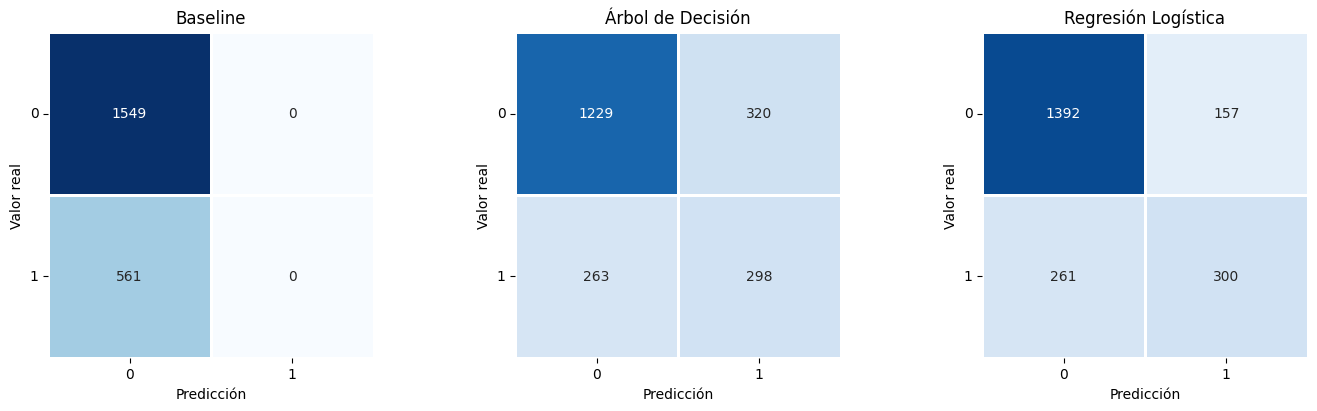

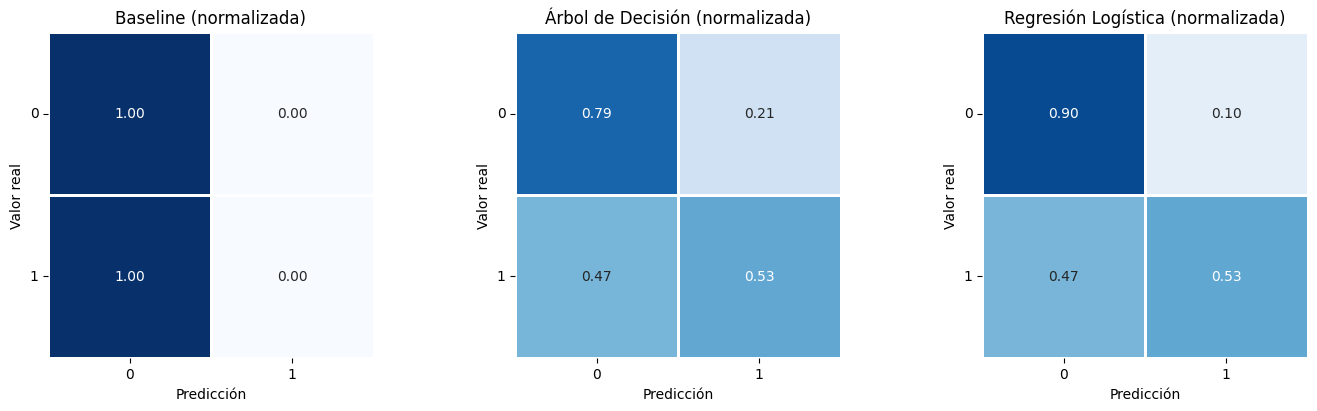

In [27]:

cm_dummy = confusion_matrix(y_test, y_pred_dummy)
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_logreg = confusion_matrix(y_test, y_pred_logreg)

cms = [cm_dummy, cm_dt, cm_logreg]
titulos = ["Baseline", "Árbol de Decisión", "Regresión Logística"]



vmax = max(cm.max() for cm in cms)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

for ax, cm, titulo in zip(axes, cms, titulos):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        vmin=0,
        vmax=vmax,
        cbar=False,
        square=True,
        linewidths=0.8,
        linecolor="white",
        ax=ax
    )
    ax.set_title(titulo)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Valor real")
    ax.set_xticklabels(["0", "1"])
    ax.set_yticklabels(["0", "1"], rotation=0)

plt.show()




fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

for ax, cm, titulo in zip(axes, cms, titulos):
    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        vmin=0,
        vmax=1,
        cbar=False,
        square=True,
        linewidths=0.8,
        linecolor="white",
        ax=ax
    )
    ax.set_title(f"{titulo} (normalizada)")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Valor real")
    ax.set_xticklabels(["0", "1"])
    ax.set_yticklabels(["0", "1"], rotation=0)

plt.show()


Análisis de desempeño del modelo

La matriz de confusión permite evaluar con mayor detalle el comportamiento del modelo al clasificar clientes que cancelan el servicio (churn) y clientes que permanecen.

El modelo logra identificar correctamente una proporción importante de clientes que no cancelan el servicio (True Negatives), lo que indica una buena capacidad para reconocer clientes estables.

Por otro lado, también identifica una parte significativa de los clientes que sí cancelan el servicio (True Positives). Esto es especialmente importante desde una perspectiva de negocio, ya que permite detectar clientes en riesgo y aplicar estrategias de retención antes de que abandonen la empresa.

Sin embargo, también se presentan algunos falsos negativos, es decir, clientes que el modelo clasifica como estables pero que finalmente cancelan el servicio. Este tipo de error representa una oportunidad de mejora, ya que implica clientes que podrían perderse sin haber recibido acciones preventivas.

En general, el modelo muestra un desempeño equilibrado, lo cual es adecuado para problemas de predicción de churn, donde el objetivo principal es identificar la mayor cantidad posible de clientes con riesgo de cancelación.

### Importancia de las variables

In [28]:
ohe = preprocessor.named_transformers_["cat"]
encoded_cat_cols = ohe.get_feature_names_out(categorical_cols)

feature_names = np.concatenate([encoded_cat_cols, datos_num])

len(feature_names)

29

In [29]:
coeficientes = logreg_pipeline.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "Variable": feature_names,
    "Coeficiente": coeficientes
})

coef_df.head()

,Variable,Coeficiente
0,customer.gender_Male,-0.044843
1,customer.Partner_Yes,-0.102912
2,customer.Dependents_Yes,-0.068790
3,phone.PhoneService_Yes,-0.276002
4,phone.MultipleLines_No,-0.226596


In [30]:
top_positive = coef_df.sort_values("Coeficiente", ascending=False).head(10)
top_positive

,Variable,Coeficiente
27,account.Charges.Total,1.158362
8,internet.InternetService_Fiber optic,0.651236
16,account.Contract_Month-to-month,0.563092
19,account.PaperlessBilling_Yes,0.365989
14,internet.StreamingTV_Yes,0.251539
24,customer.SeniorCitizen,0.251448
22,account.PaymentMethod_Electronic check,0.231368
15,internet.StreamingMovies_Yes,0.156995
26,account.Charges.Monthly,0.126901
28,Cuentas_Diarias,0.126901


In [31]:
top_negative = coef_df.sort_values("Coeficiente").head(10)
top_negative


,Variable,Coeficiente
25,customer.tenure,-2.961971
9,internet.InternetService_No,-0.842396
18,account.Contract_Two year,-0.714486
13,internet.TechSupport_Yes,-0.400953
10,internet.OnlineSecurity_Yes,-0.293878
3,phone.PhoneService_Yes,-0.276002
21,account.PaymentMethod_Credit card (automatic),-0.251231
4,phone.MultipleLines_No,-0.226596
20,account.PaymentMethod_Bank transfer (automatic),-0.171120
17,account.Contract_One year,-0.165052


### Variables más influyentes

/tmp/ipykernel_883/884464380.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


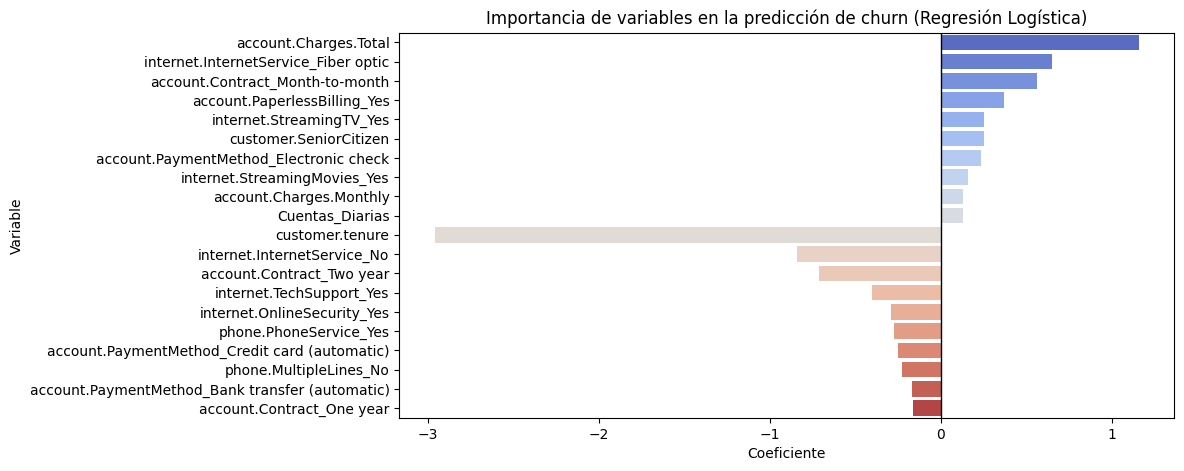

In [32]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=pd.concat([top_positive, top_negative]),
    x="Coeficiente",
    y="Variable",
    palette="coolwarm"
)

plt.title("Importancia de variables en la predicción de churn (Regresión Logística)")
plt.axvline(0, color="black", linewidth=1)
plt.show()

El análisis de importancia de variables permitió identificar los factores que tienen mayor impacto en la probabilidad de cancelación de los clientes.

Entre las variables más relevantes se destacan:

Antigüedad del cliente
Esta variable presenta una fuerte relación con la cancelación. Los clientes con menor tiempo en la empresa muestran una mayor tendencia a abandonar el servicio, lo que indica que los primeros meses son críticos para consolidar la relación con el cliente.

Cargos totales acumulados
Los clientes con mayor gasto total suelen ser aquellos que han permanecido más tiempo en la empresa, lo que reduce la probabilidad de cancelación. Esto sugiere que la permanencia prolongada genera mayor fidelización.

Método de pago y tipo de contrato
Algunos métodos de pago y tipos de contrato muestran mayor asociación con la cancelación. Los contratos de corto plazo suelen presentar mayores tasas de churn en comparación con los contratos de largo plazo, lo cual es consistente con la lógica del negocio.

En conjunto, estas variables permiten comprender mejor el comportamiento de los clientes y proporcionan información clave para diseñar estrategias de retención más efectivas.

## Conclusiones generales

El análisis realizado permitió identificar patrones importantes asociados a la cancelación de clientes (Churn) en Telecom X.

Los resultados del análisis exploratorio mostraron que la antigüedad del cliente (tenure) es uno de los factores más influyentes en la cancelación, ya que los clientes con menor tiempo en la empresa presentan una mayor probabilidad de abandonar el servicio. Esto sugiere que los primeros meses de relación con el cliente representan un período crítico para su retención.

También se observó que los clientes que cancelan tienden a tener un gasto total acumulado menor, lo cual está relacionado con su menor permanencia en la compañía. En contraste, los clientes que permanecen más tiempo generan mayor valor económico para la empresa.

En la etapa de modelado se evaluaron diferentes algoritmos de clasificación. Entre ellos, la Regresión Logística mostró el mejor desempeño general, logrando un equilibrio adecuado entre precisión, recall y F1-score. Esto indica que el modelo es capaz de identificar de forma más efectiva a los clientes con riesgo de cancelar el servicio.

El Árbol de Decisión también logró detectar patrones relevantes, aunque con un rendimiento ligeramente inferior. Por su parte, el modelo baseline presentó un desempeño limitado, lo cual era esperado ya que su función principal es servir como referencia mínima de comparación.

Finalmente, el análisis de importancia de variables permitió identificar los factores que más influyen en la predicción de cancelación, proporcionando información valiosa para la toma de decisiones estratégicas.

## Recomendaciones

A partir de los resultados obtenidos, se proponen las siguientes acciones para reducir la tasa de cancelación de clientes:

1. Fortalecer la retención durante los primeros meses del cliente

Dado que los clientes con menor antigüedad presentan mayor probabilidad de cancelar el servicio, la empresa podría implementar estrategias específicas durante los primeros meses, como programas de acompañamiento, beneficios iniciales o atención personalizada.

2. Diseñar programas de fidelización

Los clientes con mayor tiempo en la empresa presentan menor probabilidad de cancelar. Por lo tanto, desarrollar programas de fidelización, descuentos por permanencia o beneficios por antigüedad puede incentivar la retención a largo plazo.

3. Identificar clientes en riesgo mediante modelos predictivos

El modelo de regresión logística desarrollado en este análisis podría utilizarse como una herramienta para identificar clientes con alta probabilidad de cancelación. Esto permitiría aplicar acciones preventivas antes de que el cliente abandone el servicio.

4. Analizar servicios y costos asociados al churn

Dado que el gasto mensual también muestra relación con la cancelación, es recomendable analizar si ciertos planes o combinaciones de servicios generan mayor insatisfacción o percepción de alto costo por parte de los clientes.

5. Implementar estrategias de retención basadas en datos

Integrar modelos predictivos dentro de los sistemas de gestión de clientes permitiría tomar decisiones basadas en datos, priorizando acciones comerciales sobre los clientes con mayor riesgo de cancelación.